# Notebook for X-Ray Light curve model Project

In [1]:
from plot_results import *
from chandra_phase_analysis import *
import pandas as pd
import numpy as np
import os
from xspec import (
        AllData,
        AllModels,
        Spectrum,
        Model,
        Fit,
        Xset,
        Plot,
)

In [5]:
# Generate model lightcurve in soft energy band
os.system("python xrb_lightcurve.py \
--flux_method interpolate \
--flux_csv flux_vs_nH_phabs_soft.csv \
--output sim_flux_interpolate_phabs_soft.csv \
--i0 10.0 --lam 0.589454 --lam2 0.589454 --r 0.1 --R 10 --converge-rmax")

Starting XRB Lightcurve Simulation...
Parameters:
  r (emitter radius): 0.1 solar radii
  R (companion radius): 10.0 solar radii
  d1 (emitter separation): 11.0 solar radii
  d2 (companion separation): 8.0 solar radii
  gma0 (starting phase): -90.0 degrees
  i0 (inclination): 10.0 degrees
  dth (orbital increment): 1.0 degrees
  d2h (polar cell size): 6.0 degrees
  dz (LOS step size): 0.1
  Rmax (LOS cutoff): 38.0
  converge_rmax: True
  n_jobs (parallel workers): 1
  flux_method: interpolate
  flux_csv: flux_vs_nH_phabs_soft.csv
  lam: 0.589454
  lam2: 0.589454
  Output file: sim_flux_interpolate_phabs_soft.csv

Detected energy bands in CSV: soft

Simulation completed! Results saved to sim_flux_interpolate_phabs_soft.csv
Total data points: 360
Phase range: -90.00 to 269.00 degrees


/Users/rpanchal/Desktop/xrb_lc/XRB_LightCurve/xrb_lightcurve.py:413: UserWarning: Some nH values are outside CSV range [0.000, 361.042] 1e22 cm^-2 for band 'soft'. Extrapolation will be used (fill_value='extrapolate').
  warnings.warn(
/Users/rpanchal/Desktop/xrb_lc/XRB_LightCurve/xrb_lightcurve.py:413: UserWarning: Some nH values are outside CSV range [0.000, 361.042] 1e22 cm^-2 for band 'soft'. Extrapolation will be used (fill_value='extrapolate').
  warnings.warn(


0

Detected energy bands: ['soft']


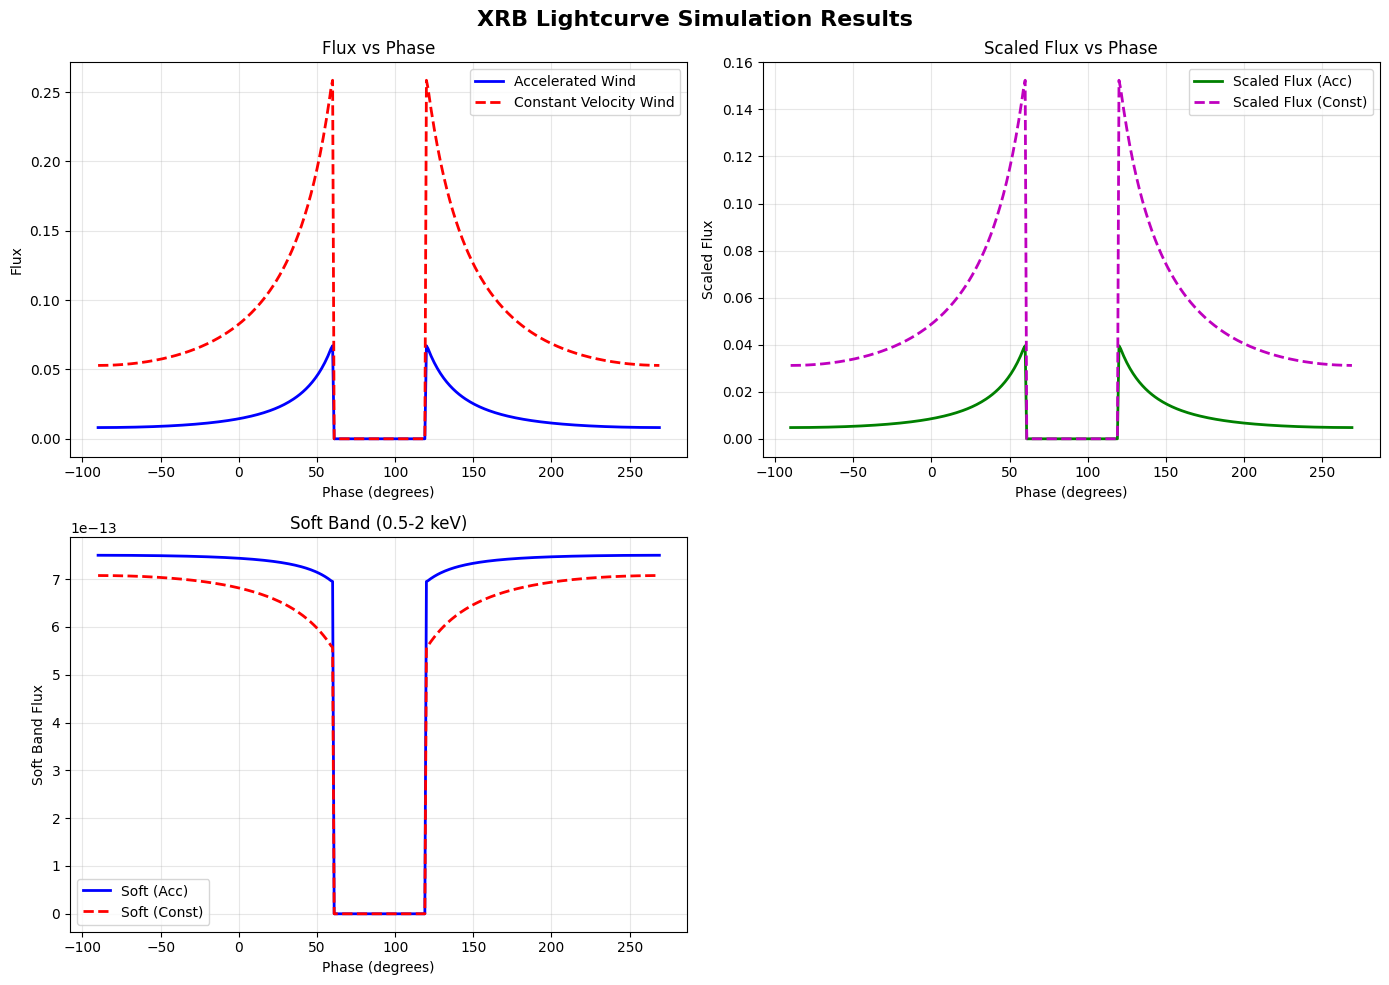

In [6]:
# Plot model Lightcurve
plot_lightcurve("sim_flux_interpolate_phabs_soft.csv")

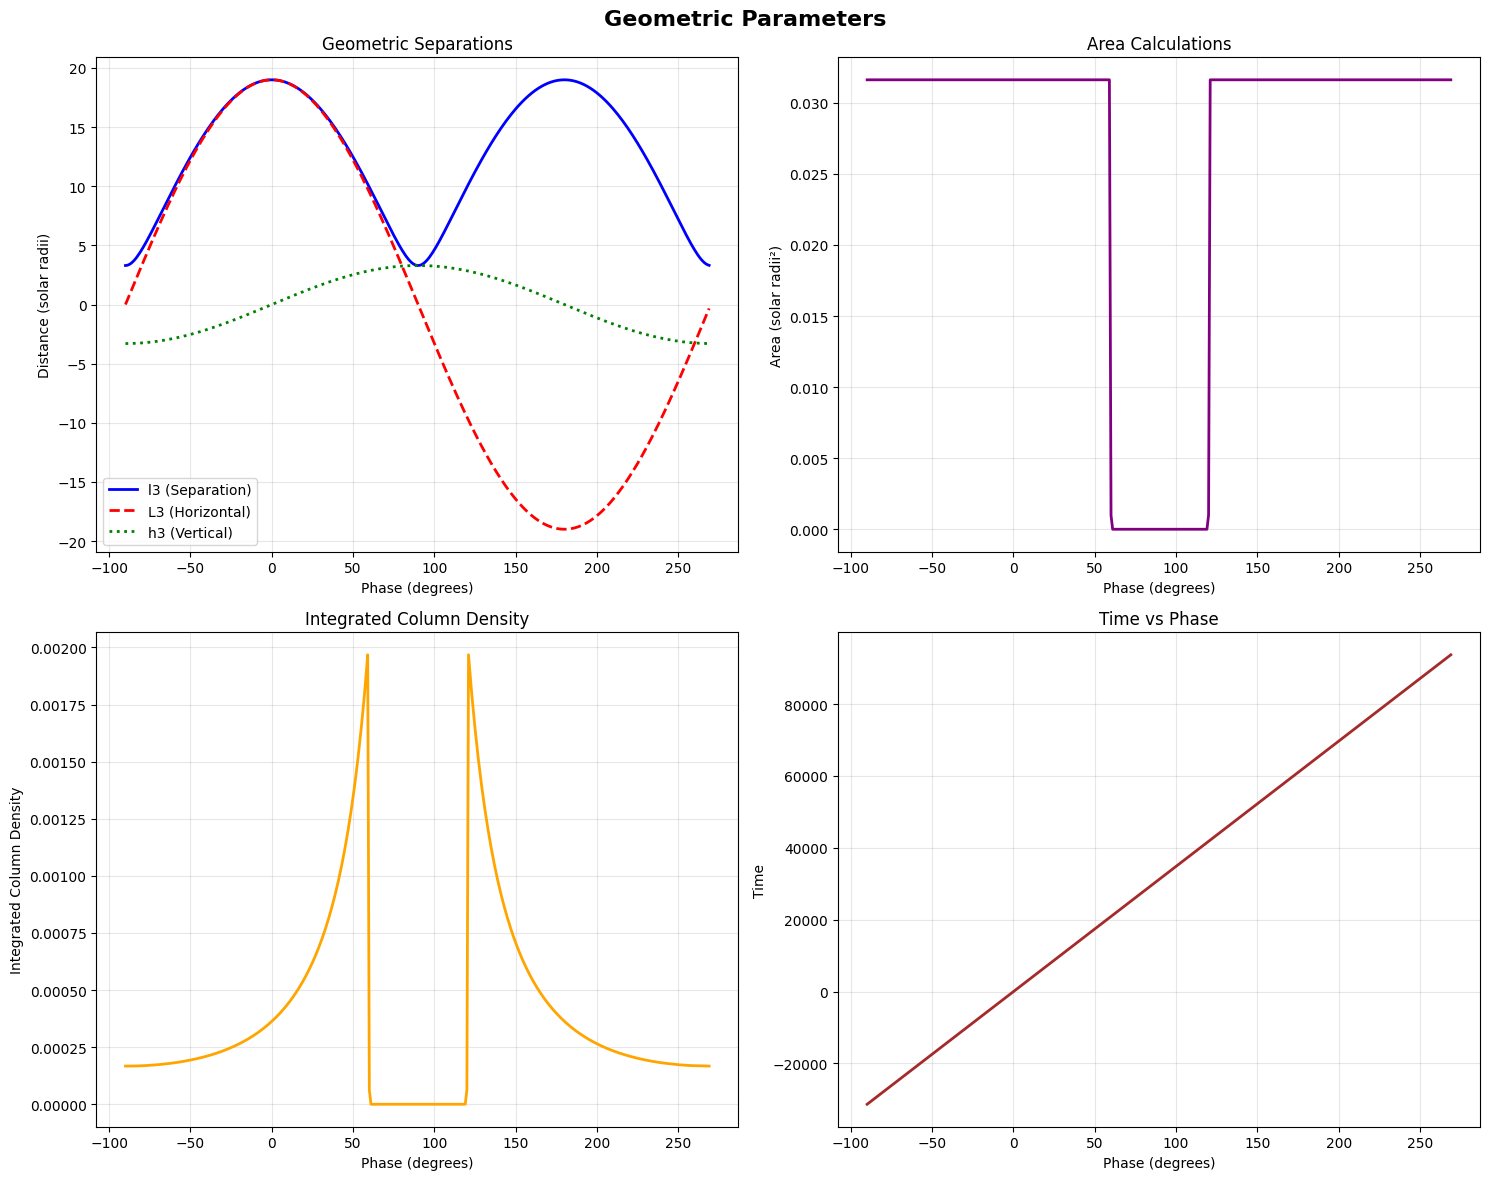

In [6]:
plot_geometric_parameters("sim_flux_interpolate_phabs_soft.csv")

## IC10X1 spectrum: XSpec model

In [4]:
from compute_flux_vs_nH import *
specdir = "data/IC10X1_spec"
instrument = "chandra"
src, bkg, rmf, arf = find_spectrum_files(specdir)
load_data(src, bkg, rmf, arf)


1 spectrum  in use
 
Spectral Data File: X1_spectrum_combined_src.pi  Spectrum 1
Net count rate (cts/s) for Spectrum:1  6.920e-02 +/- 5.839e-04 (95.8 % total)
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: CHANDRA Instrument: ACIS  Channel Type: PI
  Exposure Time: 2.178e+05 sec
 Using fit statistic: chi
 Using Background File                X1_spectrum_combined_bkg.pi
  Background Exposure Time: 2.178e+05 sec
 Using Response (RMF) File            X1_spectrum_combined_src.rmf for Source 1
 Using Auxiliary Response (ARF) File  X1_spectrum_combined_src.arf

Net count rate (cts/s) for Spectrum:1  6.920e-02 +/- 5.839e-04 (95.8 % total)


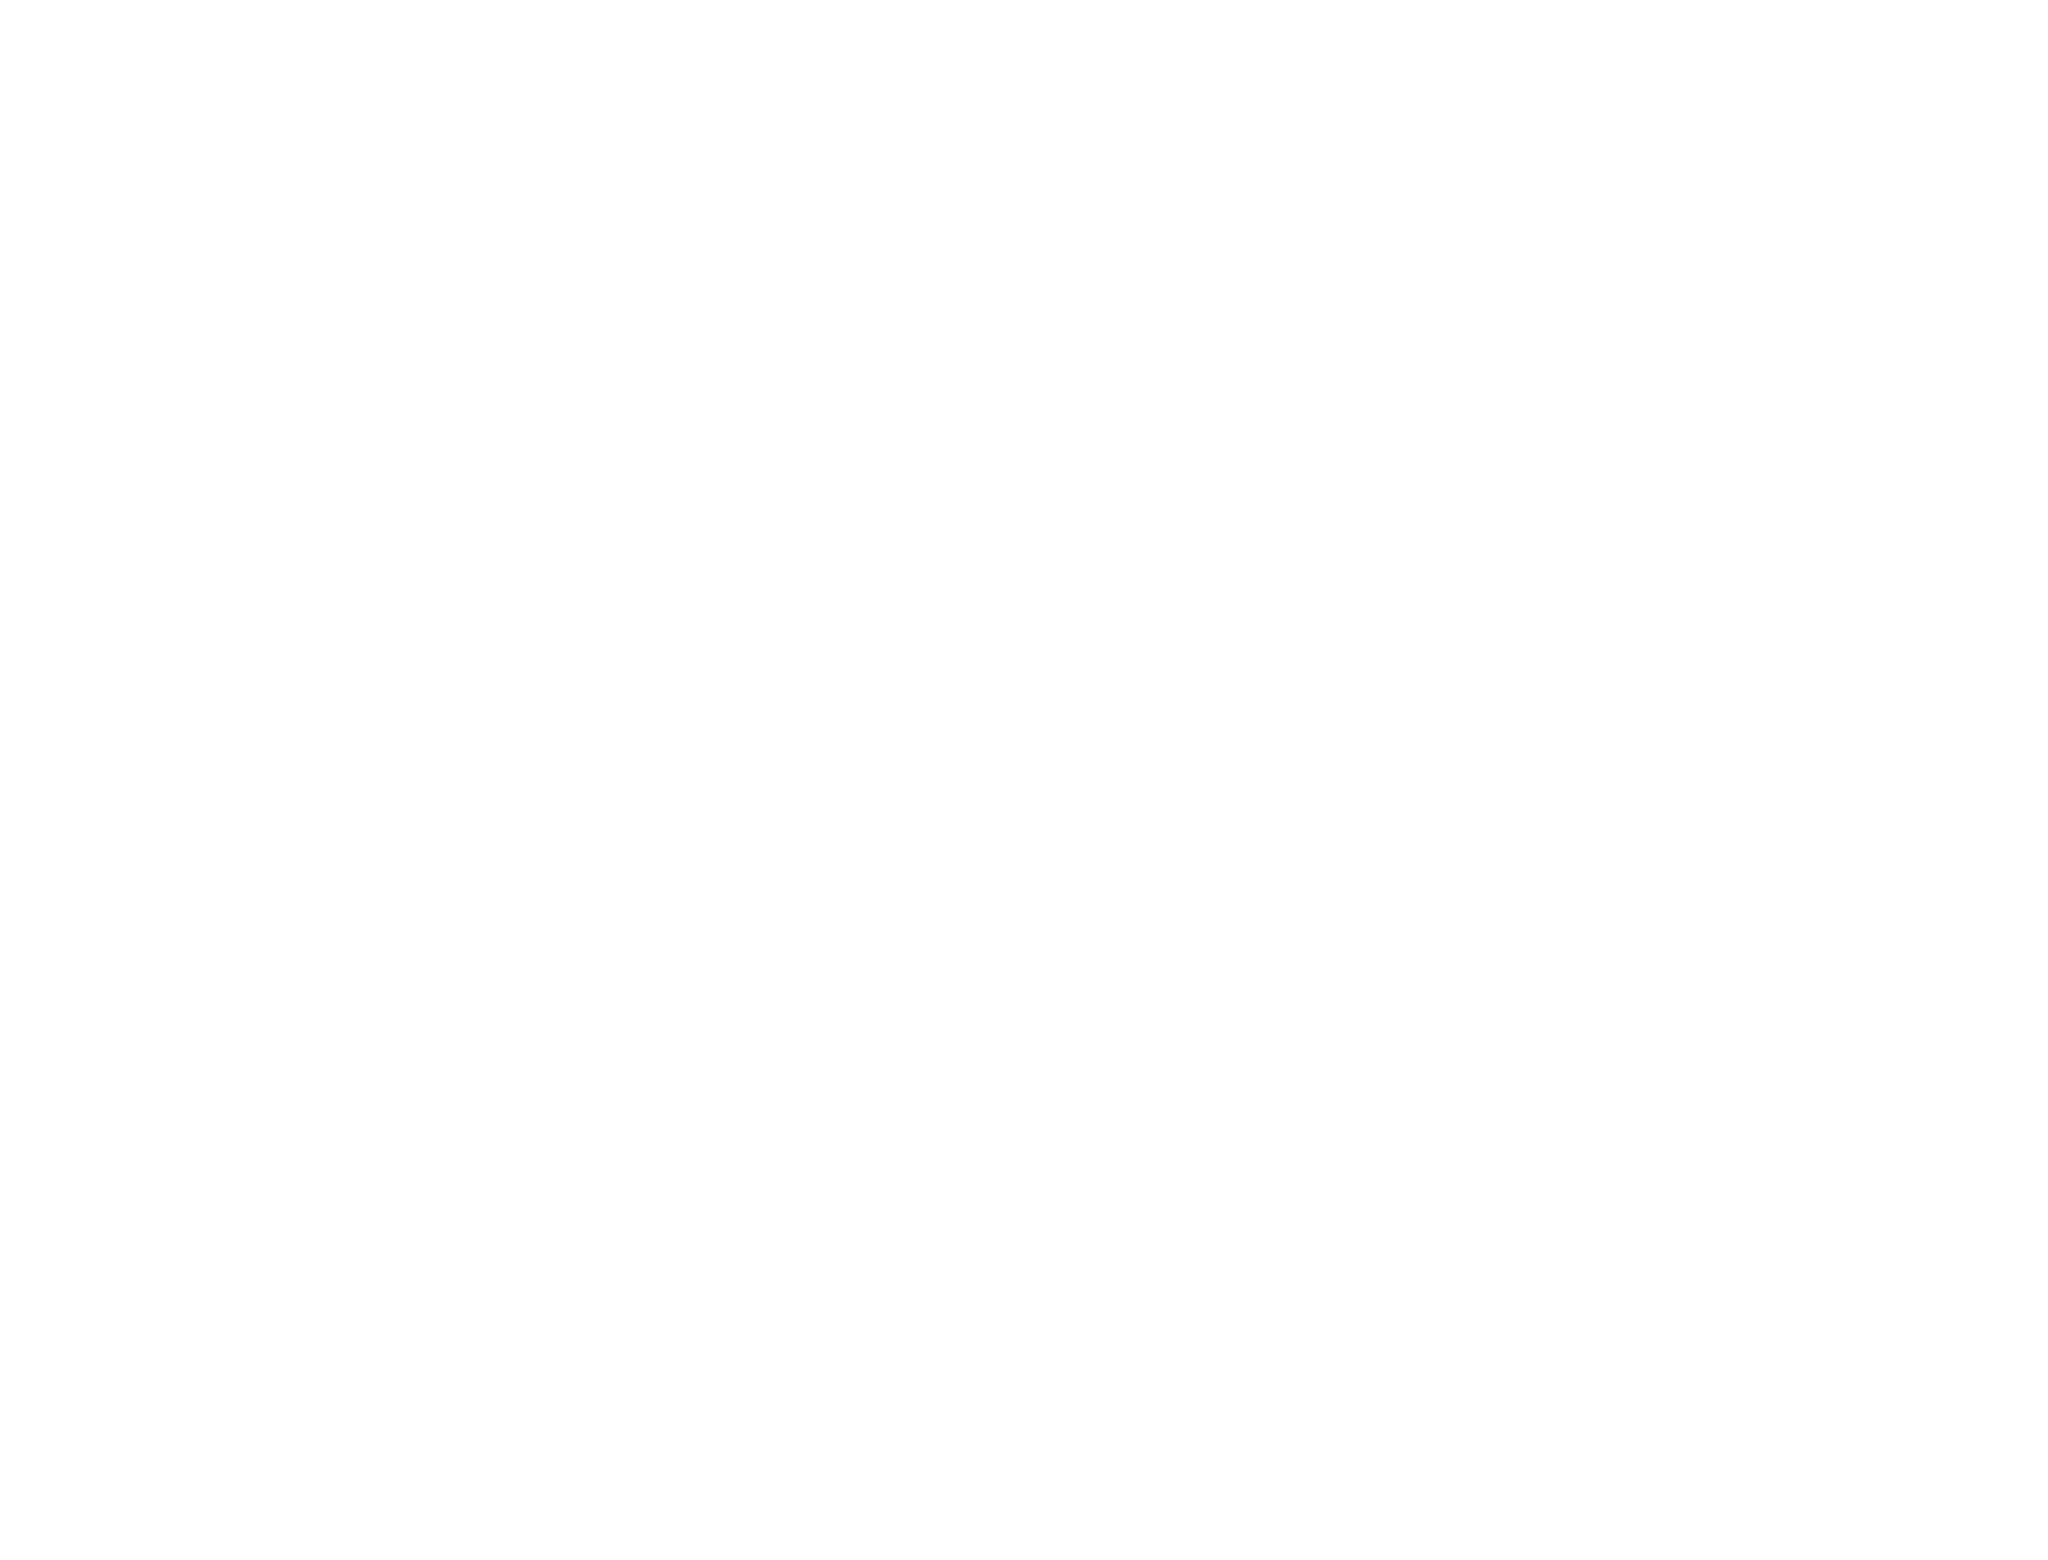

In [5]:
# Plot spectrum data
Plot.device = "/svg"
Plot.xAxis = "KeV"
Plot("data")

In [18]:
# Load an absorber model with powerlaw
m1 = Model("tbabs*(po+bb)")
m1.powerlaw.PhoIndex = 1.92146
m1.powerlaw.norm = 3.37606e-04
m1.TBabs.nH = 0.5
m1.bbody.kT = 1.0
m1.show()


Model TBabs<1>(powerlaw<2> + bbody<3>) Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    1.00000      +/-  0.0          
   2    2   powerlaw   PhoIndex            1.00000      +/-  0.0          
   3    2   powerlaw   norm                1.00000      +/-  0.0          
   4    3   bbody      kT         keV      3.00000      +/-  0.0          
   5    3   bbody      norm                1.00000      +/-  0.0          
________________________________________________________________________


Fit statistic  : Chi-Squared              5.431495e+12     using 1024 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number: 1

Test statistic : Chi-Squared              5.431495e+12     using 1024 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 0.000000e+00 with 1019

In [19]:
# Fit model with data
Fit.perform()
Fit.show()

                                   Parameters
Chi-Squared  |beta|/N    Lvl          1:nH    2:PhoIndex        3:norm          4:kT        5:norm
3341.15      1.99561e+06   0      0.430187       7.22713   5.87108e-06      0.985115   1.48934e-05
2621.83      5.80653e+06   0      0.396911       6.53646   4.47700e-06      0.902312   1.42143e-05
2498.56      3.73937e+06  -1     0.0128710       2.00014   1.99566e-06      0.863376   1.15614e-05
1757.34      3.48561e+07  -1     0.0441212      -2.29939   2.20602e-08      0.840054   1.12045e-05
1481.25      1.34816e+08  -2      0.165053     -0.342558   1.66074e-07      0.730741   1.04069e-05
1330.45      1.62372e+07   0      0.165842      -1.11688   3.68566e-07      0.731879   1.04202e-05
1276.19      3.11119e+07   0      0.170429      -1.28830   4.91585e-07      0.731210   1.03982e-05
1266.25      6.87146e+06  -1      0.181765      -1.24642   6.05393e-07      0.715836   1.02097e-05
1261.96      2.91169e+06  -1      0.184591      -1.17826   7.16

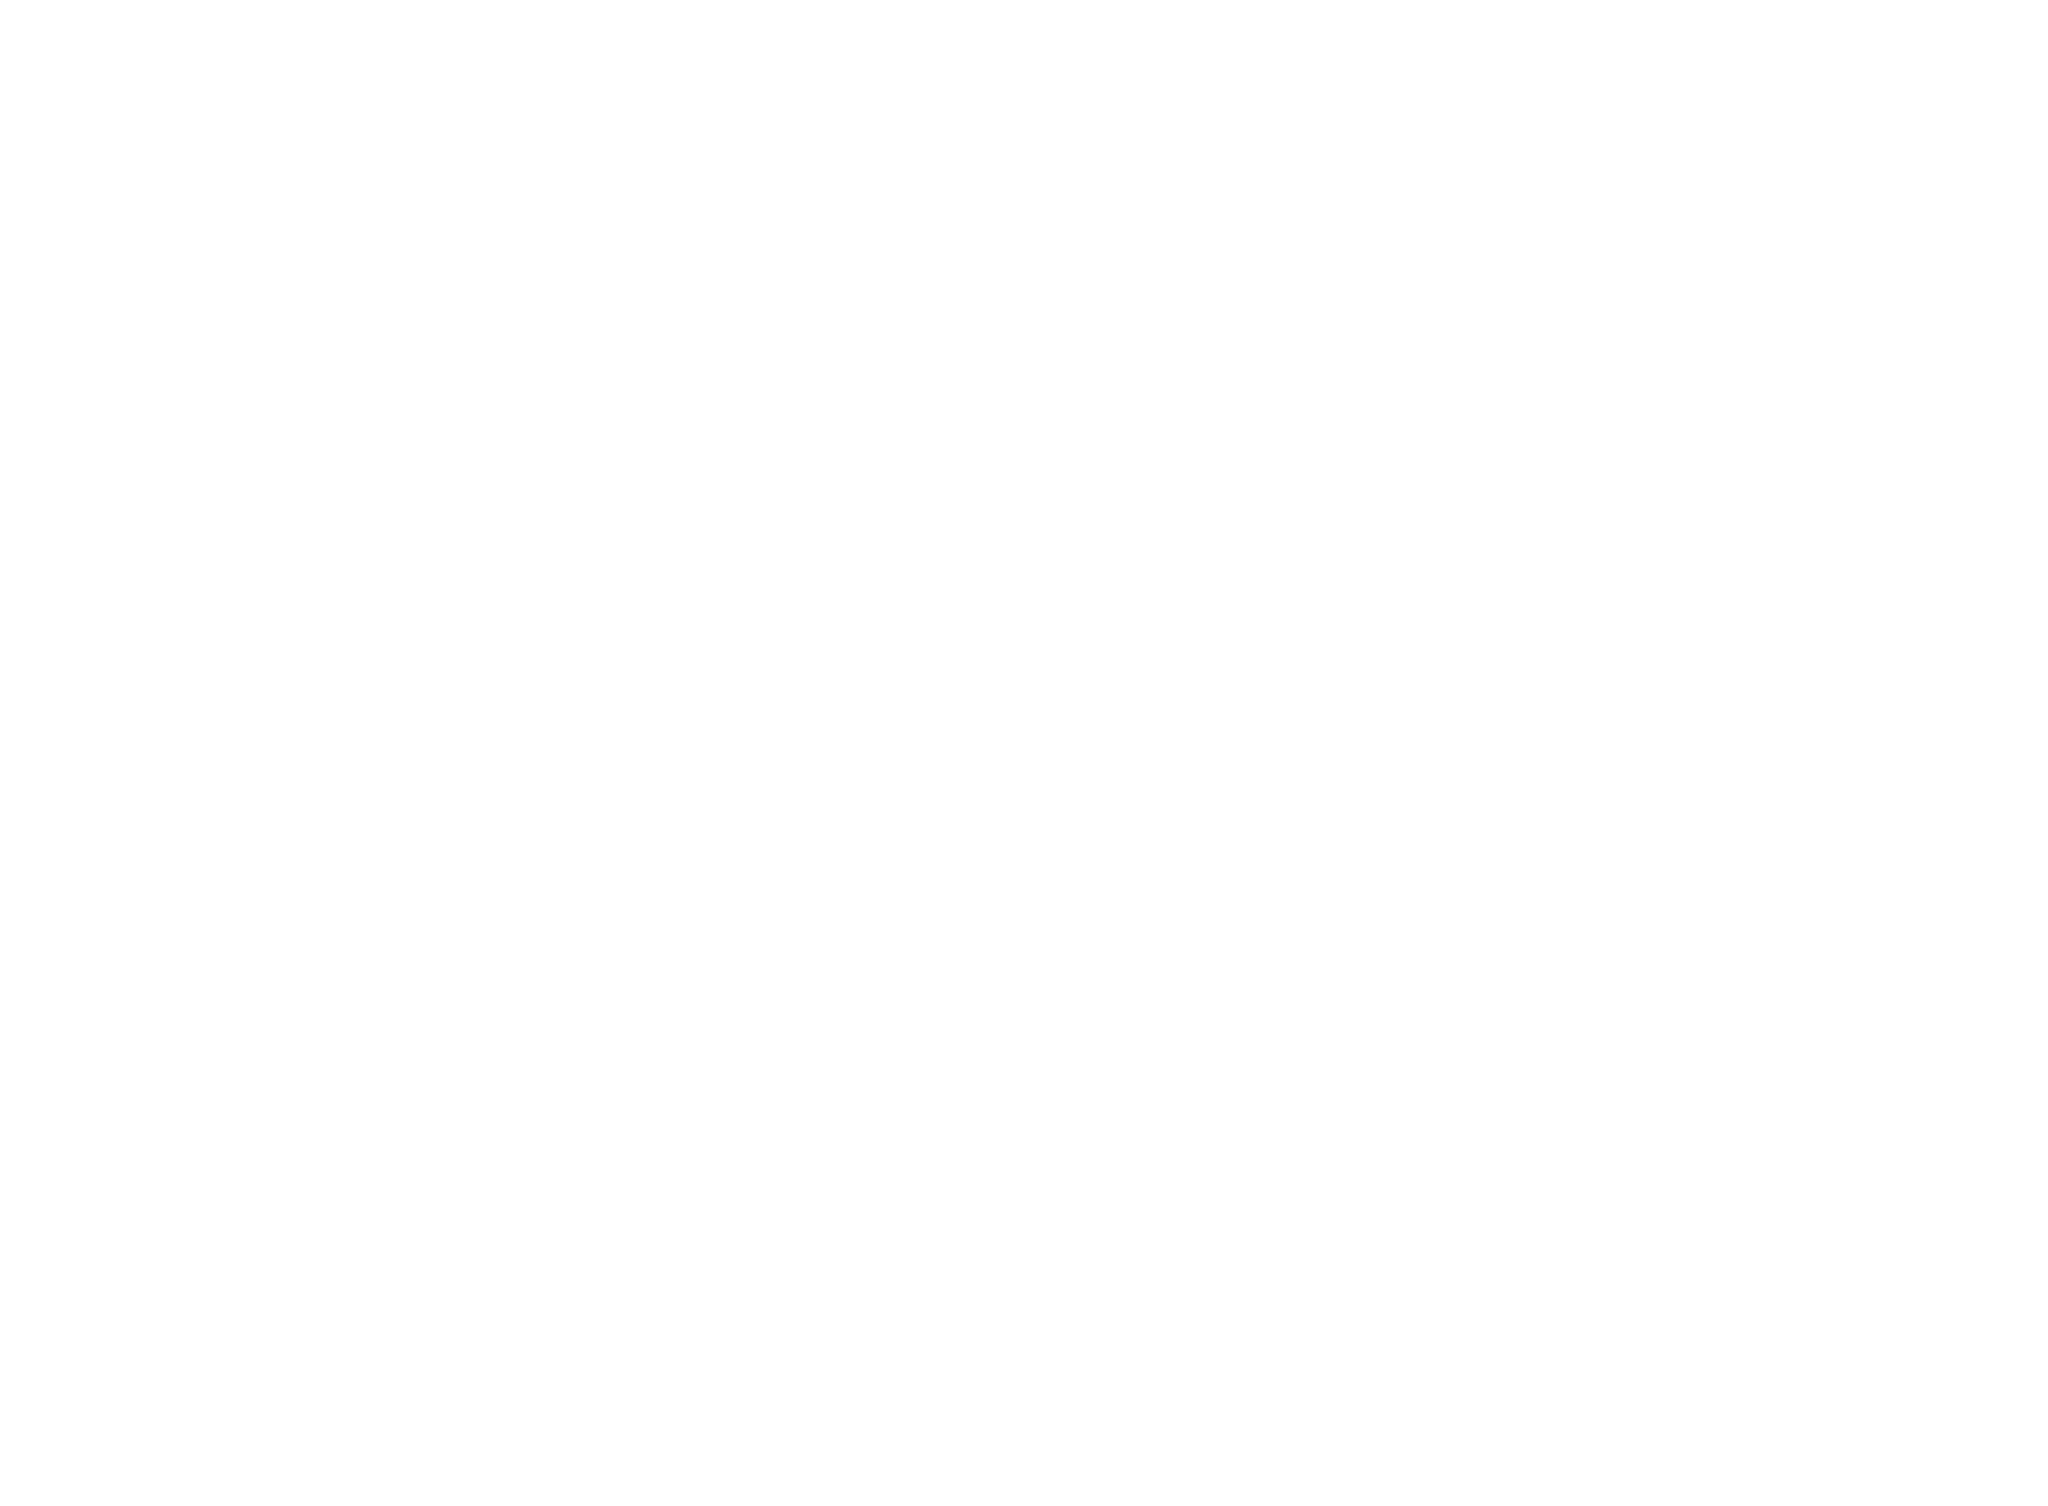

In [20]:
Plot("Model","data","res")